我们应该知道softmax回归的细节----

In [15]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

## d2l.load_data_fashion_mnist 函数

- 功能：加载 Fashion-MNIST 数据集，返回训练集和测试集的数据迭代器。
- 参数 `batch_size`：每个批次的样本数量，例如 256。
- 返回值：
  - `train_iter`：训练集迭代器，元素为 `(图像批次, 标签批次)`。
  - `test_iter`：测试集迭代器，结构相同。
- 内部步骤：
  1. 定义转换 `ToTensor()`：PIL 图像 → 32 位浮点张量，像素值归一化到 0~1。
  2. 下载并读取训练集和测试集（若已存在则直接读取）。
  3. 分别创建 `DataLoader`：训练集 `shuffle=True` 打乱，测试集不打乱；并设置多进程加载。
  4. 返回两个数据迭代器。
- 优点：封装繁琐的数据准备过程，一行代码即可获得可用于训练的数据流。
- 典型用法：`train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)`，然后直接在 `for` 循环中使用。

我们之前的图片是28X28，通道数为1，但是softmax函数需要的是一个向量，所以我们需要把图片展开
## Softmax 回归参数初始化

- `num_inputs = 28 * 28`：每张 Fashion-MNIST 图像展平后得到 784 个像素值，作为输入特征数。
- `num_outputs = 10`：数据集有 10 个类别，输出维度为 10。
- `w = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)`：
  - 形状 `(784, 10)` 的权重矩阵。
  - 从均值为 0、标准差为 0.01 的正态分布随机初始化。
  - `requires_grad=True` 使该参数参与梯度计算。
- `b = torch.zeros(num_outputs, requires_grad=True)`：
  - 长度为 10 的偏置向量，初始化为 0。
  - 同样需要梯度，用于训练更新。

**关键点**  
- 权重初始化使用较小标准差，有助于训练稳定，避免 softmax 输出过于饱和。  
- 偏置初始化为 0 是常见做法，不会破坏对称性（因为权重已经随机）。  
- 两个参数都需要 `requires_grad=True`，否则优化器无法更新它们。

In [16]:
num_inputs=28*28
num_outputs=10 #数据集有10个类别-输出维度为10

w=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)

给定矩阵X，可以对所有元素求和

In [17]:
def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(1,keepdim=True)
    return X_exp/partition  #应用了广播机制

实现softmax模型

In [18]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,w.shape[0])),w) + b)

创建一个y-hat，其中包含2个样本在3个类别时的预测概率，使用y作为y-hat中概率的索引

第一个索引列表 [0, 1] 表示选择第 0 行和第 1 行（即两个样本）。
第二个索引列表 y = [0, 2] 表示在对应的行中分别选择第 0 列和第 2 列。

In [19]:
y=torch.tensor([0,2])
y_hat=torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
print(y_hat[[0,1],y])

tensor([0.1000, 0.5000])


In [20]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])
print(cross_entropy(y_hat, y))


tensor([2.3026, 0.6931])


In [21]:
def accuracy(y_hat, y):
    "计算预测正确的数量"
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)  # 取每行最大值的索引作为预测类别
    cmp = y_hat.type(y.dtype) == y    # 预测类别与真实标签比较
    return float(cmp.type(y.dtype).sum())  # 返回正确预测的数量


## accuracy 函数：计算预测正确数量

- 参数：
  - `y_hat`：模型输出，可为概率矩阵 `(n, 类别数)` 或类别索引 `(n,)`
  - `y`：真实标签向量，形状 `(n,)`
- 步骤：
  1. 若 `y_hat` 是概率矩阵（二维且列数 > 1），用 `argmax(axis=1)` 取每行最大值的索引，得到预测类别向量。
  2. 将预测类别向量与 `y` 类型统一后比较（`==`），得到布尔张量（True 表示预测正确）。
  3. 将布尔张量转为整数（True→1, False→0）并求和，即正确样本数。
- 返回：正确预测的数量（浮点数），便于后续累加计算准确率。

**示例**：
`y = [0, 2]`，`y_hat = [[0.1,0.3,0.6],[0.3,0.2,0.5]]`
→ `argmax` 得 `[2, 2]` → 比较得 `[False, True]` → 求和为 `1.0`。

**关键点**
- `argmax(axis=1)` 用于从概率矩阵中提取预测类别。
- `type(y.dtype)` 确保比较双方类型一致。
- 布尔求和是一种常用的统计正确数量的方法。


我们可以评估在任意模型上net的正确率

In [22]:
def evaluate_accuracy(net,data_iter):
    "计算指定数据集上的模型精度"
    if isinstance(net,torch.nn.Module):
        net.eval()
    metric = d2l.Accumulator(2)
    for X, y in data_iter:
        metric.add(accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]
print(evaluate_accuracy(net,test_iter))

0.0626


## evaluate_accuracy 函数：计算模型在数据集上的平均准确率

- 作用：评估模型在整个数据迭代器上的分类精度。
- 与 `accuracy` 的关系：`accuracy` 只计算单批正确数，本函数在其基础上累加多批并求比例，是泛化/扩展版本。
- 关键步骤：
  1. `isinstance(net, torch.nn.Module)` 判断是否神经网络模块；若是，调用 `net.eval()` 进入评估模式。
  2. 创建 `Accumulator(2)`：两个槽位分别累加正确样本数和总样本数。
  3. 遍历数据迭代器，对每个批次：
     - `net(X)` 前向传播得到预测。
     - `accuracy(net(X), y)` 计算该批正确数。
     - `y.numel()` 获得该批样本总数。
     - `metric.add(正确数, 样本总数)` 累加。
  4. 返回 `metric[0] / metric[1]`，即正确总数 / 样本总数，得到平均准确率。

**注意**  
- 评估时应使用 `net.eval()`，若之后继续训练需调用 `net.train()` 切回训练模式。  
- `Accumulator` 是 d2l 工具类，可用简单列表 + 循环替代。

softmax回归的训练

In [ ]:
def train_epoch_ch3(net,train_iter,loss,updater):
    if isinstance(net,torch.nn.Module):
        net.train()
    metric =d2l.Accumulator(3)
    for X, y in train_iter:
        y_hat=net(X)
        l=loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
    return metric[0]/metric[2],metric[1]/metric[2]

## train_epoch_ch3 函数：训练模型一个 epoch

- **作用**：遍历整个训练集一次（一个 epoch），完成"前向传播 → 算损失 → 反向传播 → 更新参数"的完整训练循环，返回本轮的**平均损失**和**平均准确率**。

- **参数**：
  - `net`：模型（手写的 `net` 函数或 `torch.nn.Module`）。
  - `train_iter`：训练集数据迭代器，每次产出 `(X, y)`。
  - `loss`：损失函数（本例为手写的 `cross_entropy`）。
  - `updater`：参数更新器（`torch.optim.Optimizer` 或手写的 `sgd` 函数）。

- **关键步骤**：
  1. `isinstance(net, torch.nn.Module)` 判断是否为框架模型；若是，调用 `net.train()` 切换训练模式。
  2. 创建 `Accumulator(3)`：三个槽位分别累加 **[总损失, 正确数, 总样本数]**。
  3. 遍历每个批次 `(X, y)`：
     - `y_hat = net(X)`：前向传播得到预测概率。
     - `l = loss(y_hat, y)`：计算损失（此时 `l` 是**向量**，不是标量）。
     - 根据 `updater` 类型走两条路径（见下方对比）。
     - `metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())`：累加总损失、正确数、样本数。
  4. 返回 `metric[0]/metric[2]`（平均损失）和 `metric[1]/metric[2]`（准确率）。

- **两条更新路径对比**：

  | | `torch.optim.Optimizer` 分支 | 手写 updater 分支（else） |
  |---|---|---|
  | 适用场景 | PyTorch 内置优化器（如 `SGD`） | 自己实现的 `sgd` 函数 |
  | 梯度聚合 | `l.mean().backward()` 按均值反向传播 | `l.sum().backward()` 按总和反向传播 |
  | 更新方式 | `updater.step()` 一行搞定 | `updater(X.shape[0])` 手动传批次大小 |
  | 本质 | 两种数学上等价（学习率差一个批次倍数） | |

- **`metric` 三个槽的含义**：
  - `metric[0]` = 所有批次损失之和
  - `metric[1]` = 所有批次预测正确的样本数
  - `metric[2]` = 所有批次样本总数

- **返回值**：`(平均损失, 平均准确率)`，即 `(metric[0]/metric[2], metric[1]/metric[2])`。

**关键点**
- `l` 是向量（每样本一个损失值），`backward()` 前必须先 `.sum()` 或 `.mean()` 聚合成标量，否则报错：`grad can be implicitly created only for scalar outputs`。
- `net.train()` 和 `net.eval()` 要配对使用：训练时开、评估时关。
- `isinstance()` 用于兼容"框架优化器"和"手写优化器"两种方式。

**注意（已修正的 bug）**
- `l.backward()` → `l.mean().backward()`：向量要先聚合成标量。
- `float(1) * len(y)` → `float(l.sum())`：这个槽要存总损失，不是批次大小。
- `y.size.numel` / `y.size.numel()` → `y.numel()`：`y.size` 是 `torch.Size` 对象，没有 `numel`，正确写法是 `y.numel()`。

**`y.numel()` vs `y.size` vs `len(y)` 速查**

| 写法 | 返回类型 | 含义 |
|------|---------|------|
| `y.numel()` | `int` | 元素总个数 |
| `y.size` | `torch.Size` | 形状对象（类似 tuple） |
| `len(y)` | `int` | 第 0 维的长度 |


定义一个在动画中绘制数据的实用程序类


In [ ]:
class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        from matplotlib_inline.backend_inline import set_matplotlib_formats; set_matplotlib_formats('png')
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

训练函数

In [25]:
def train_ch3(net,train_iter,test_iter,loss,num_epochs,updater):
    animator=Animator(xlabel='epoch', xlim=[1,num_epochs],ylim=[0.3,0.9],
                      legend=['train loss','train acc','test acc'])
    for epoch in range(num_epochs):
        train_metrics=train_epoch_ch3(net,train_iter,loss,updater)
        test_acc=evaluate_accuracy(net,test_iter)
        animator.add(epoch+1,train_metrics+(test_acc,))
    train_loss,train_acc=train_metrics
    return train_loss,train_acc

In [26]:
lr=0.1
def updater(batch_size):
    return d2l.sgd([w,b],lr,batch_size)

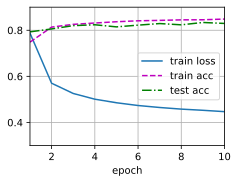

In [27]:
num_epochs=10
train_ch3(net,train_iter,test_iter,cross_entropy,num_epochs,updater)